QUEREMOS CALCULAR LOS NIVELES DE ENERGIA DEL OSCILADOR ARMÓNICO QUÁNTICO
Usando el método de diferencias finitas y diagonalización de matrices.
----------------------------------------------------------------------------------------------------
------------------------------------------------------------------
Niveles de energía del sistema:  [0 1 2 3 4 5]
Nivel n=0, Energía E=0.9999, Energía E=1.0000
Nivel n=1, Energía E=2.9997, Energía E=3.0000
Nivel n=2, Energía E=4.9993, Energía E=5.0000
Nivel n=3, Energía E=6.9987, Energía E=7.0000
Nivel n=4, Energía E=8.9979, Energía E=9.0000
Nivel n=5, Energía E=10.9969, Energía E=11.0000


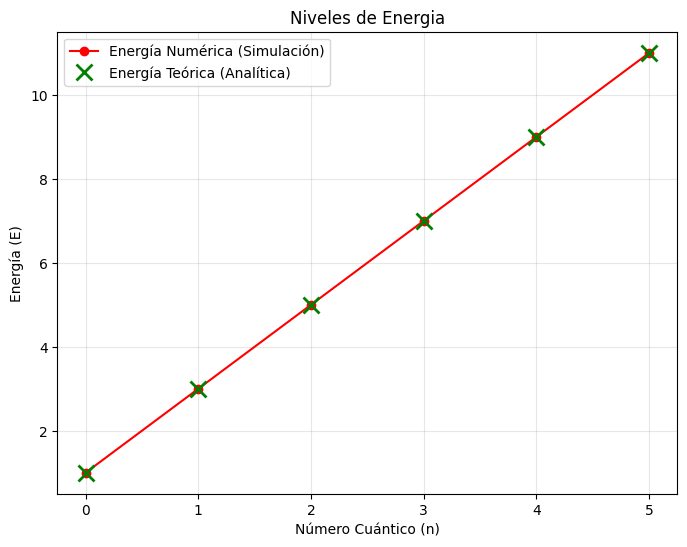

Error absoluto del modelo: 0.003063096664231324
Porcentaje de error (%): 0.027846333311193853


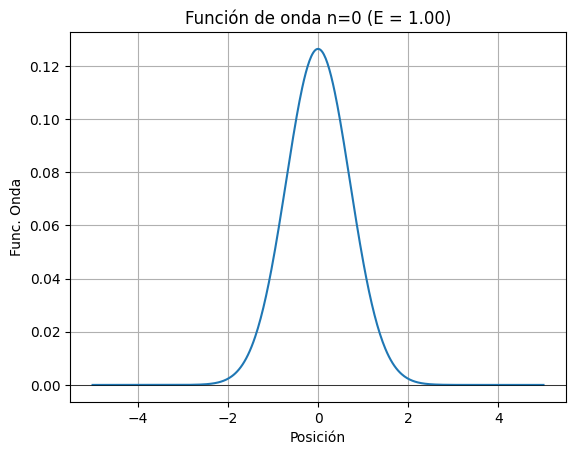

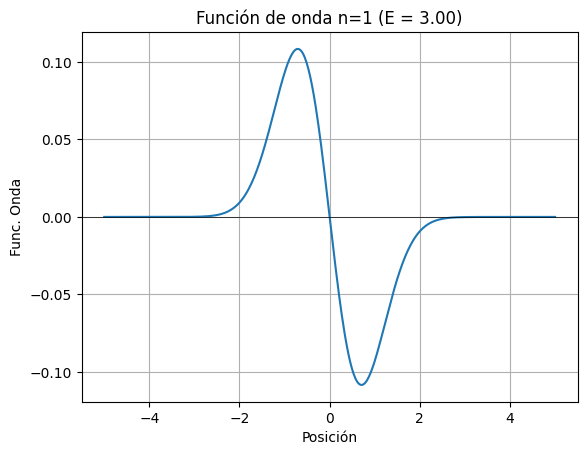

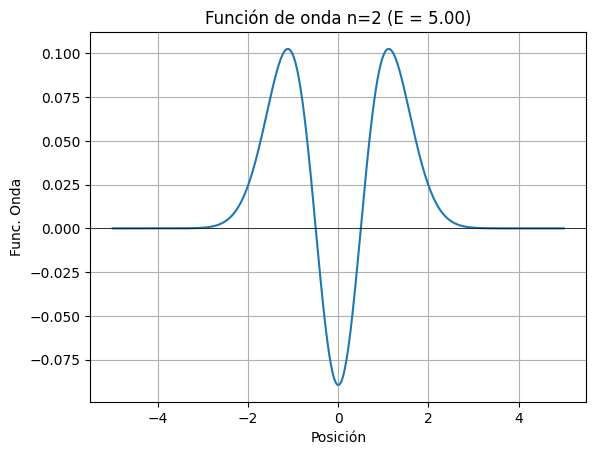

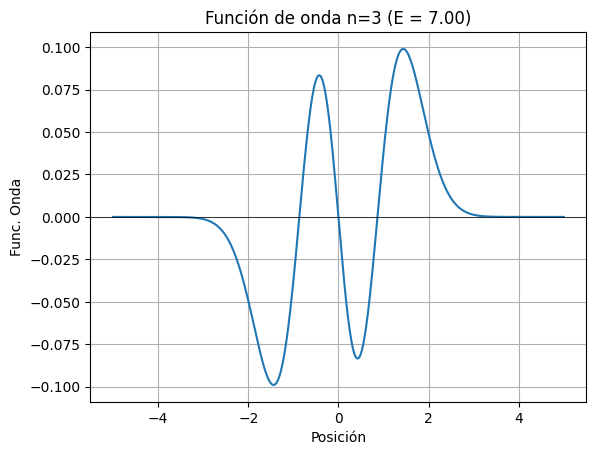

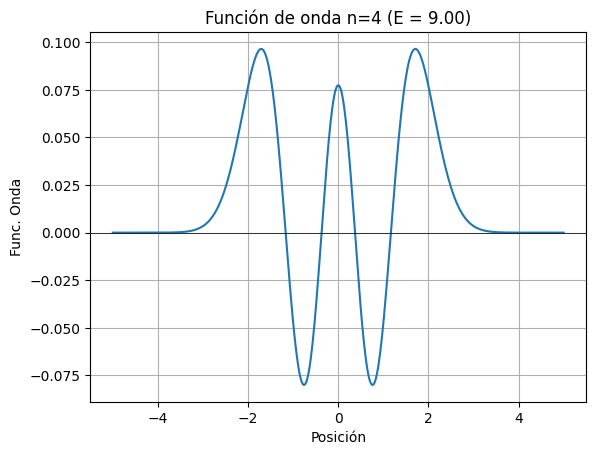

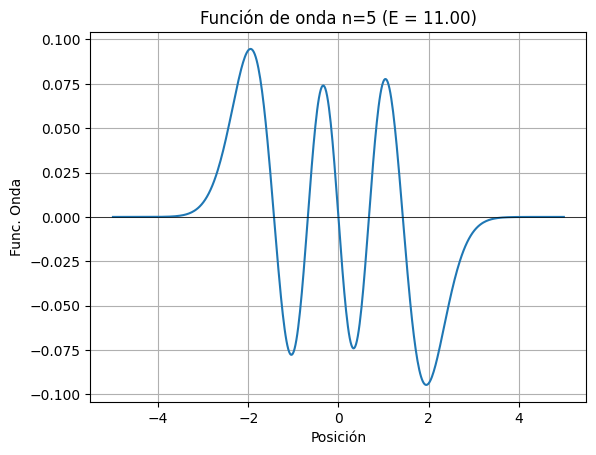

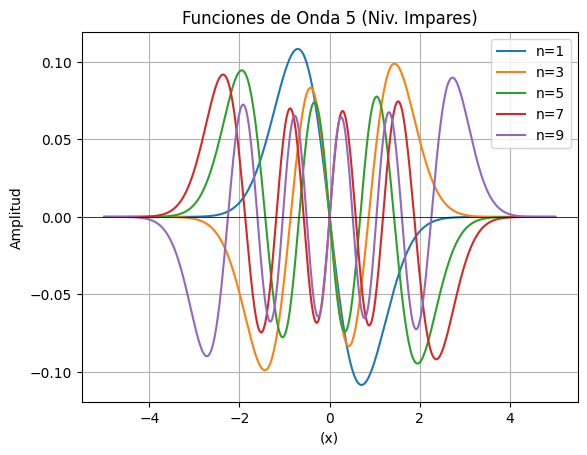

In [1]:

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# Unidades naturales
hbar = 1
m = 1
omega = 2 # frecuencia
N = 500 #La malla de continuo a discreto
L_min = -5
L_max = 5
x = np.linspace(L_min, L_max, N) #Discretizar
dx = x[1] - x[0]

print('QUEREMOS CALCULAR LOS NIVELES DE ENERGIA DEL OSCILADOR ARMÓNICO QUÁNTICO')
print('Usando el método de diferencias finitas y diagonalización de matrices.')
print('----------------------------------------------------------------------------------------------------')
n_levels = np.arange(0, 6)  #Elegir los niveles de energia
print('------------------------------------------------------------------')
print("Niveles de energía del sistema: ",n_levels)

# Definimos el Potencial como matriz
V_array = 0.5 * m * (omega**2) * (x**2)
V = np.diag(V_array)

# CINÉTICA
# Como estamos usando una malla discreta (puntos separados por dx), no podemos derivar analíticamente. Usamos la "Fórmula de Diferencias Finitas Centradas".
#                     ψ(i+1) - 2*ψ(i) + ψ(i-1)
#   d^2_ψ / dx^2 ≈ --------------------------------    fuente: https://mathworld.wolfram.com/Derivative.html
#                                 dx^2
comp_traza = -2 * np.ones(N) # En la matriz 500x500
resto_matrix  = np.ones(N-1) # Diagonales secundarias
# Construimos la matriz
D2 = (np.diag(comp_traza, k=0) +
      np.diag(resto_matrix,  k=1) +
      np.diag(resto_matrix,  k=-1))
D2 = D2 / (dx**2)
T = -((hbar**2) / (2 * m)) * D2


# HAMILTONIANOA
H = T + V
VAPS, VEPS = la.eigh(H) #DIAGONALIZACIÓM Autovalores -> energia; autovectores -> Ondas


def ener(n, hbar, omega): # Energía
	return hbar * omega * (n + 0.5)

# Creamos dos listas vacías para ir guardando los valores
lista_E_num = []
lista_E_teo = []

for i in n_levels:
    E_num = VAPS[i]
    E_t = ener(i, hbar, omega) #Nos dará el calculo continuo para comparar con el discreto (E_num con los VAPS)
	# Calculamos la energía para el nivel actual 'i'
    lista_E_num.append(VAPS[i]) # Guardamos la numérica
    lista_E_teo.append(ener(i, hbar, omega)) # Guardamos la teórica
    print(f'Nivel n={i}, Energía E={E_num:.4f}, Energía E={E_t:.4f}') #.4f para 4 decimales

# -- GRAFICO ENERGIAS --
plt.figure(figsize=(8, 6))

# A) Energía Numérica: Línea roja que conecta los puntos donde cae la numerica
# 'r-o' significa: red (rojo), línea sólida (-), con puntos (o) en cada n
plt.plot(n_levels, lista_E_num, 'r-o', label='Energía Numérica (Simulación)')
# B) Energía Teórica: Cruces verdes
# 'gx' significa: green (verde), forma de cruz (x)
plt.plot(n_levels, lista_E_teo, 'gx', markersize=12, markeredgewidth=2, label='Energía Teórica (Analítica)')
plt.title('Niveles de Energia')
plt.xlabel('Número Cuántico (n)')
plt.ylabel('Energía (E)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(n_levels)

plt.show()

print('Error absoluto del modelo:', np.abs(E_num - E_t))
print('Porcentaje de error (%):', np.abs((E_num - E_t) / E_t) * 100)

#Graf. Funciones de onda
for i in n_levels:
    E_num = VAPS[i]
    psi = VEPS[:, i]
    plt.plot(x, psi) # Usamos plot en vez de scatter para una línea contínua
    plt.title(f'Función de onda n={i} (E = {E_num:.2f})')
    plt.xlabel('Posición')
    plt.ylabel('Func. Onda')
    plt.grid(True) #Añade una cuadrícula o rejilla al fondo del gráfico.
    plt.axhline(0, color='black', linewidth=0.5) # Añade línea en y=0
    plt.show()

#GRAF. COMBINAT
n_levels3 = np.arange(1, 10, 2) #imaprells
for i in n_levels3:
	func = VEPS[:, i]

	plt.plot(x, func, label=f'n={i}')

plt.title('Funciones de Onda 5 (Niv. Impares)')
plt.xlabel('(x)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.legend()
plt.show()

